# 06 — Final Analysis



In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/jakirJisan")

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_ROOT}. "
        "Make sure the extracted folder is directly inside MyDrive."
    )

print("Project root:", PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/jakirJisan


In [2]:
import subprocess
import sys

requirements_file = PROJECT_ROOT / "requirements" / "analysis.txt"
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_file)
])
print("Analysis dependencies installed.")

Analysis dependencies installed.


In [3]:
import sys

project_path = str(PROJECT_ROOT)
if project_path not in sys.path:
    sys.path.insert(0, project_path)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis import RUNS, load_master_results, question_type_scores
from src.config import ProjectConfig

project = ProjectConfig(project_root=PROJECT_ROOT)
results = load_master_results(project.results_dir)
display(results.round(6))

,method,rank,total_parameters,trainable_parameters,trainable_percent,validation_em,validation_f1,validation_blank_percent,test_em,test_f1,test_blank_percent,training_time_seconds,peak_gpu_memory_gb,energy_kwh,co2_kg,post_training_loss
0,Full Fine-Tuning,NaN,60506624,60506624,100.000000,48.977136,64.068129,0.0,46.162528,59.086167,0.0,401.914477,2.009934,0.008740,0.003052,0.123221
1,LoRA r=4,4.0,60654080,147456,0.243110,37.545126,51.067576,0.0,37.810384,48.890098,0.0,423.284383,1.181859,0.008880,0.002535,0.512102
2,LoRA r=8,8.0,60801536,294912,0.485040,44.524669,58.799541,0.0,43.679458,55.724593,0.0,370.468393,1.184520,0.007848,0.002741,0.249020
3,LoRA r=16,16.0,61096448,589824,0.965398,47.653430,62.185953,0.0,46.049661,58.904288,0.0,387.972743,1.189841,0.008295,0.003905,0.100903
4,LoRA r=32,32.0,61686272,1179648,1.912335,48.014440,63.734872,0.0,47.742664,61.786341,0.0,386.342810,1.200484,0.008224,0.001141,0.042658


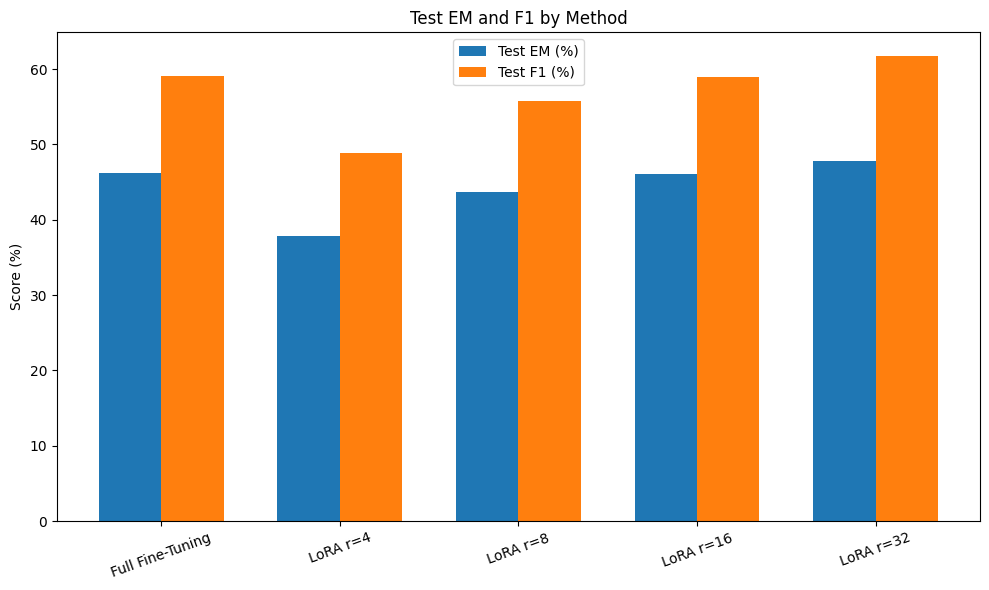

In [5]:
# Test EM/F1 comparison
labels = results["method"].tolist()
x = list(range(len(results)))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width / 2 for i in x], results["test_em"], width=width, label="Test EM (%)")
plt.bar([i + width / 2 for i in x], results["test_f1"], width=width, label="Test F1 (%)")
plt.xticks(x, labels, rotation=20)
plt.ylabel("Score (%)")
plt.title("Test EM and F1 by Method")
plt.legend()
plt.tight_layout()
plt.show()

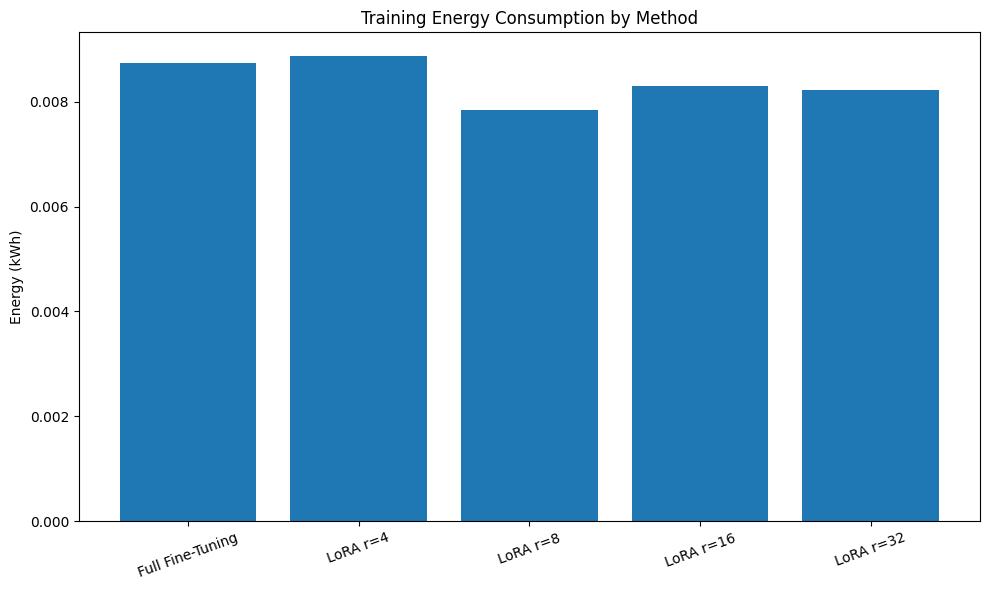

In [6]:
# Training energy comparison
plt.figure(figsize=(10, 6))
plt.bar(results["method"], results["energy_kwh"])
plt.xticks(rotation=20)
plt.ylabel("Energy (kWh)")
plt.title("Training Energy Consumption by Method")
plt.tight_layout()
plt.show()

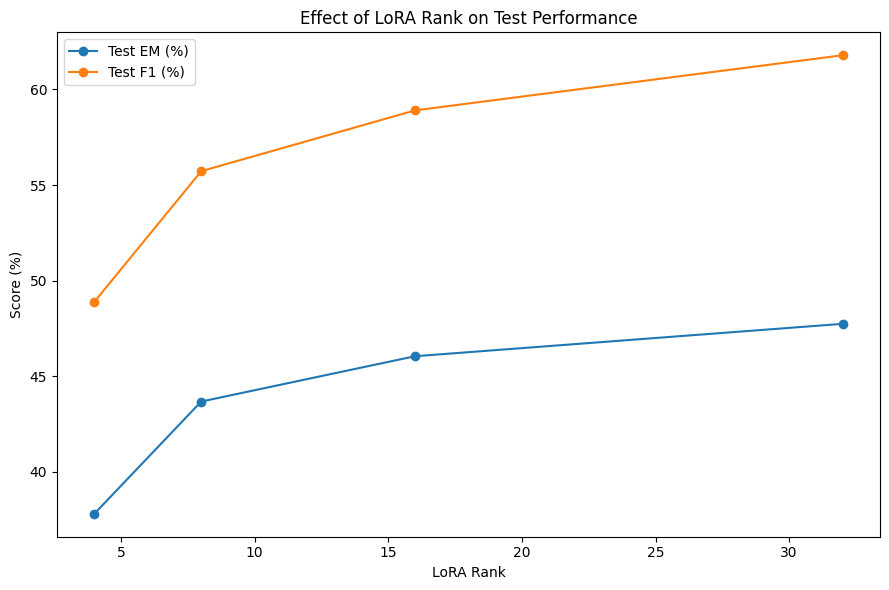

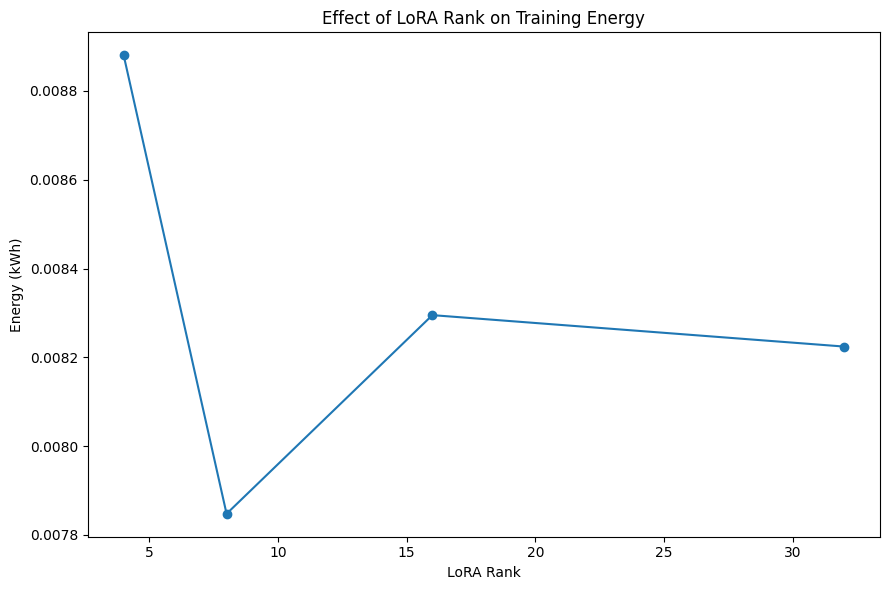

In [7]:
# LoRA rank trends
lora = results[results["rank"].notna()].copy().sort_values("rank")

plt.figure(figsize=(9, 6))
plt.plot(lora["rank"], lora["test_em"], marker="o", label="Test EM (%)")
plt.plot(lora["rank"], lora["test_f1"], marker="o", label="Test F1 (%)")
plt.xlabel("LoRA Rank")
plt.ylabel("Score (%)")
plt.title("Effect of LoRA Rank on Test Performance")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(lora["rank"], lora["energy_kwh"], marker="o")
plt.xlabel("LoRA Rank")
plt.ylabel("Energy (kWh)")
plt.title("Effect of LoRA Rank on Training Energy")
plt.tight_layout()
plt.show()

In [9]:
# Question-type analysis from saved test predictions
import gdown
import pandas as pd
from pathlib import Path

# Google Drive IDs for the 5 prediction files
PRED_FILES = {
    "full_ft": "1dF48hKVK8dDZPf16TL5TQuzPJjGbL2u4",
    "lora_r4": "14EpI0kTgeEMawzq--JSSTAnRYva1F2Fp",
    "lora_r8": "1WGjkN4JHmosrRr8FjaCY1JvnFvohL06c",
    "lora_r16": "1QL6nQmeOeTUMf-DzNNLVHu4R5UozCHzA",
    "lora_r32": "1LlFSWNs9v7d7t8EqzbIDwVeKSzYgNAX1"
}

project.results_dir.mkdir(parents=True, exist_ok=True)
model_names = dict(zip(RUNS, results["method"]))
frames = []

for run in RUNS:
    pred_path = project.results_dir / f"{run}_test_predictions.csv"

    # Auto-download from Google Drive if missing
    if not pred_path.exists():
        fid = PRED_FILES.get(run)
        if fid:
            print(f"Downloading {pred_path.name}...")
            gdown.download(id=fid, output=str(pred_path), quiet=False)

    if pred_path.exists():
        predictions = pd.read_csv(pred_path)
        frames.append(question_type_scores(predictions, model_names[run]))
    else:
        print(f"Warning: {pred_path.name} could not be found or downloaded, skipping.")

if frames:
    question_type = pd.concat(frames, ignore_index=True)
    display(question_type.round(2))
else:
    print("No prediction files available.")


Downloading...
From (original): https://drive.google.com/uc?id=1dF48hKVK8dDZPf16TL5TQuzPJjGbL2u4
From (redirected): https://drive.google.com/uc?id=1dF48hKVK8dDZPf16TL5TQuzPJjGbL2u4&confirm=t&uuid=c1aba008-5e5b-43a6-92d5-30152e2ce6bb
To: /content/drive/MyDrive/jakirJisan/results/full_ft_test_predictions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 71.2MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=14EpI0kTgeEMawzq--JSSTAnRYva1F2Fp
From (redirected): https://drive.google.com/uc?id=14EpI0kTgeEMawzq--JSSTAnRYva1F2Fp&confirm=t&uuid=2997cced-bcea-462d-82ed-15ff457216e2
To: /content/drive/MyDrive/jakirJisan/results/lora_r4_test_predictions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 84.4MB/s]


Downloading...
From: https://drive.google.com/uc?id=1WGjkN4JHmosrRr8FjaCY1JvnFvohL06c
To: /content/drive/MyDrive/jakirJisan/results/lora_r8_test_predictions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 53.7MB/s]


Downloading...
From: https://drive.google.com/uc?id=1QL6nQmeOeTUMf-DzNNLVHu4R5UozCHzA
To: /content/drive/MyDrive/jakirJisan/results/lora_r16_test_predictions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 35.3MB/s]


Downloading...
From (original): https://drive.google.com/uc?id=1LlFSWNs9v7d7t8EqzbIDwVeKSzYgNAX1
From (redirected): https://drive.google.com/uc?id=1LlFSWNs9v7d7t8EqzbIDwVeKSzYgNAX1&confirm=t&uuid=132d27f6-b0db-45f2-8ffc-bc05878a02ad
To: /content/drive/MyDrive/jakirJisan/results/lora_r32_test_predictions.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 65.5MB/s]


,Model,question_type,Questions,EM,F1
0,Full Fine-Tuning,causal,103,29.13,39.96
1,Full Fine-Tuning,confirmation,60,50.00,50.00
2,Full Fine-Tuning,factoid,622,52.09,65.13
3,Full Fine-Tuning,list,101,24.75,46.74
4,LoRA r=4,causal,103,31.07,39.46
5,LoRA r=4,confirmation,60,21.67,21.67
6,LoRA r=4,factoid,622,44.21,54.92
7,LoRA r=4,list,101,14.85,37.54
8,LoRA r=8,causal,103,37.86,45.40
9,LoRA r=8,confirmation,60,36.67,36.67
